# Phase 3 — Target Distribution & Regression "Balancing"

Regression → **no SMOTE / over- / under-sampling** (those are classification tools and would fabricate rents).
This notebook decides two things:

1. **Split design**: should the 70/15/15 split be stratified on target bins (`pd.qcut(y, q=5)`)?
   Bins are **only for splitting**, never features.
2. **Target transform**: train on `log1p(Rent)` (back-transform with `np.expm1`, report in rupees) or raw `Rent`?
   Per the leakage rules this is decided on **train-only** evidence.

The split built here uses the exact Phase-5 recipe, so Phase 5 reproduces the same indices; nothing is saved.
Val/test targets are only used for a *split-balance* summary (quantiles); no model sees them (`EVALUATE_TEST = False`).

Colab: upload `House_Rent_Dataset.csv` into the working directory, then *Runtime → Run all*.

In [1]:
import time, hashlib, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import make_scorer, mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50); pd.set_option("display.width", 140)
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
EVALUATE_TEST = False
TARGET = "Rent"
raw = pd.read_csv("House_Rent_Dataset.csv")
print("Raw shape:", raw.shape)

Raw shape: (4746, 12)


## 0. Phase-2 cleaning code (copied verbatim from `phase2_cleaning.ipynb`)

In [2]:
# ======================= PHASE-2 STATELESS RULES — COPY VERBATIM INTO PHASE 5 =======================
TEXT_COLS = ["Posted On", "Floor", "Area Type", "Area Locality", "City",
             "Furnishing Status", "Tenant Preferred", "Point of Contact"]
FLOOR_LEVEL_MAP = {"Ground": 0, "Upper Basement": -1, "Lower Basement": -2}


def rule_strip_text(df):
    df = df.copy()
    for c in TEXT_COLS:
        df[c] = df[c].astype(str).str.strip()
    df["Area Locality"] = (df["Area Locality"].str.lower()
                           .str.replace(r"[^a-z0-9]+", " ", regex=True)
                           .str.strip())
    return df


def rule_validity(df):
    ok = (df["Rent"] > 0) & (df["Size"] > 0) & (df["BHK"] >= 1) & (df["Bathroom"] >= 1)
    return df[ok]


def rule_dedup_relisted(df):
    return df.drop_duplicates(subset=[c for c in df.columns if c != "Posted On"], keep="first")


def rule_parse_floor(df):
    df = df.copy()
    parts = df["Floor"].str.split(" out of ", n=1, expand=True).reindex(columns=[0, 1])
    cur = parts[0].replace(FLOOR_LEVEL_MAP)
    df["current_floor"] = pd.to_numeric(cur, errors="coerce").astype("float64")
    df["total_floors"] = pd.to_numeric(parts[1], errors="coerce").astype("float64")
    bad = df["current_floor"] > df["total_floors"]          # NaN comparisons are False
    df.loc[bad, "total_floors"] = df.loc[bad, "current_floor"]
    return df


def rule_parse_date(df):
    df = df.copy()
    df["posted_date"] = pd.to_datetime(df["Posted On"], format="%Y-%m-%d", errors="coerce")
    return df


STATELESS_RULES = [rule_strip_text, rule_validity, rule_dedup_relisted, rule_parse_floor, rule_parse_date]


def apply_stateless_rules(df, verbose=True):
    """Apply all distribution-free rules in a fixed order. Returns (clean_df, log_df)."""
    log = []
    for rule in STATELESS_RULES:
        n_before = len(df)
        df = rule(df)
        log.append({"rule": rule.__name__, "rows_before": n_before, "rows_after": len(df),
                    "rows_removed": n_before - len(df)})
    log = pd.DataFrame(log)
    if verbose:
        print(log.to_string(index=False))
    return df.reset_index(drop=True), log
# =====================================================================================================

In [3]:
# ======================= PHASE-2 LEARNED CLEANING — COPY VERBATIM INTO PHASE 5 =======================
class LogIQRClipper(BaseEstimator, TransformerMixin):
    """Clip numeric columns to Tukey fences learned on log1p(x) of the TRAIN data.

    side: "lower", "upper" or "both". k: IQR multiplier. Fences are stored in fit; transform never
    drops rows, it only clips, so val/test can be transformed with the train-learned fences.
    """
    def __init__(self, k=1.5, side="lower"):
        self.k = k
        self.side = side

    def fit(self, X, y=None):
        L = np.log1p(np.asarray(X, dtype="float64"))
        q1, q3 = np.nanpercentile(L, 25, axis=0), np.nanpercentile(L, 75, axis=0)
        iqr = q3 - q1
        self.lower_ = np.expm1(q1 - self.k * iqr) if self.side in ("lower", "both") else np.full(L.shape[1], -np.inf)
        self.upper_ = np.expm1(q3 + self.k * iqr) if self.side in ("upper", "both") else np.full(L.shape[1], np.inf)
        self.n_features_in_ = L.shape[1]
        if hasattr(X, "columns"):
            self.feature_names_in_ = np.asarray(X.columns, dtype=object)
        return self

    def transform(self, X):
        A = np.asarray(X, dtype="float64")
        return np.clip(A, self.lower_, self.upper_)

    def get_feature_names_out(self, input_features=None):
        if input_features is not None:
            return np.asarray(input_features, dtype=object)
        return getattr(self, "feature_names_in_", np.asarray([f"x{i}" for i in range(self.n_features_in_)], dtype=object))


def train_only_far_out_mask(X_train, y_train, k=3.0):
    """Keep-mask for TRAIN rows: drop rows whose log(Rent/Size) lies beyond Tukey far-out fences (k=3)
    computed on the train rows themselves. Never call this on val/test."""
    rps = np.log(np.asarray(y_train, dtype="float64") / X_train["Size"].to_numpy(dtype="float64"))
    q1, q3 = np.percentile(rps, [25, 75]); iqr = q3 - q1
    lo, hi = q1 - k * iqr, q3 + k * iqr
    keep = (rps >= lo) & (rps <= hi)
    return keep, {"k": k, "rent_per_sqft_lower": float(np.exp(lo)), "rent_per_sqft_upper": float(np.exp(hi)),
                  "n_dropped": int((~keep).sum())}


NUM_IMPUTER = SimpleImputer(strategy="median")          # fit on X_train in Phase 5
CAT_IMPUTER = SimpleImputer(strategy="most_frequent")   # safety net (0 categorical NaNs today)
# =====================================================================================================

In [4]:
clean, _ = apply_stateless_rules(raw)
y_all = clean[TARGET]
log_y = np.log1p(y_all)
print("\nRule-cleaned rows:", len(clean))

               rule  rows_before  rows_after  rows_removed
    rule_strip_text         4746        4746             0
      rule_validity         4746        4746             0
rule_dedup_relisted         4746        4737             9
   rule_parse_floor         4737        4737             0
    rule_parse_date         4737        4737             0

Rule-cleaned rows: 4737


## 1. Target distribution (rule-cleaned data, descriptive)

,Rent (₹),log1p(Rent)
n,4737.000,4737.000
min,1200.000,7.091
p01,4000.000,8.294
median,16000.000,9.680
mean,34954.237,9.877
p99,300000.000,12.612
max,3500000.000,15.068
std,78135.241,0.936
skew,21.427,0.911
kurtosis,841.508,0.887


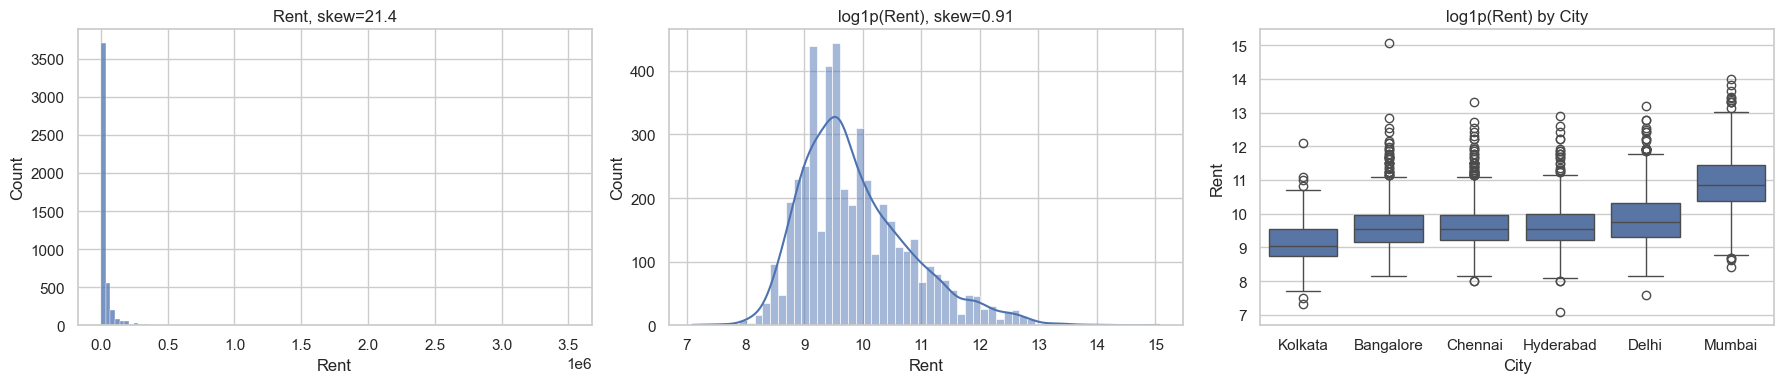

In [5]:
def describe(s):
    return pd.Series({"n": len(s), "min": s.min(), "p01": s.quantile(.01), "median": s.median(), "mean": s.mean(),
                      "p99": s.quantile(.99), "max": s.max(), "std": s.std(), "skew": s.skew(), "kurtosis": s.kurt()})
display(pd.DataFrame({"Rent (₹)": describe(y_all), "log1p(Rent)": describe(log_y)}).round(3))

fig, ax = plt.subplots(1, 3, figsize=(18, 4))
sns.histplot(y_all, bins=100, ax=ax[0]); ax[0].set_title(f"Rent, skew={y_all.skew():.1f}")
sns.histplot(log_y, bins=60, kde=True, ax=ax[1]); ax[1].set_title(f"log1p(Rent), skew={log_y.skew():.2f}")
order = clean.groupby("City")[TARGET].median().sort_values().index
sns.boxplot(x=clean["City"], y=log_y, order=order, ax=ax[2]); ax[2].set_title("log1p(Rent) by City")
plt.tight_layout(); plt.show()

### 1a. Sparse ranges

In [6]:
bands = [0, 5_000, 10_000, 20_000, 50_000, 100_000, 200_000, 500_000, np.inf]
labels = ["<5k", "5–10k", "10–20k", "20–50k", "50k–1L", "1–2L", "2–5L", ">5L"]
band = pd.cut(y_all, bands, labels=labels, right=False)
tab = pd.DataFrame({"rows": band.value_counts().reindex(labels), "share_%": (band.value_counts(normalize=True) * 100).reindex(labels).round(2)})
tab["of_which_Mumbai_%"] = (clean[band.notna()].groupby(band, observed=False)["City"]
                            .apply(lambda s: (s == "Mumbai").mean() * 100).reindex(labels).round(1))
display(tab)
print(f"Top 5% of rents span ₹{y_all.quantile(.95):,.0f} – ₹{y_all.max():,.0f}: "
      f"{y_all.max() / y_all.quantile(.95):.0f}x range held by {int((y_all >= y_all.quantile(.95)).sum())} rows.")

,rows,share_%,of_which_Mumbai_%
Rent,,,
<5k,77,1.63,1.3
5–10k,1001,21.13,2.0
10–20k,1650,34.83,4.2
20–50k,1242,26.22,28.8
50k–1L,451,9.52,65.4
1–2L,202,4.26,67.8
2–5L,101,2.13,78.2
>5L,13,0.27,76.9


Top 5% of rents span ₹130,000 – ₹3,500,000: 27x range held by 245 rows.


## 2. Split design — does stratifying on target bins help?
Compare **random** vs **qcut-stratified** 70/15/15 splits over 300 seeds: how far does each split's
target distribution drift from the full data? (Target-only statistics; no model involved.)

q=5 bin edges (₹): ['(1199.999, 9000.0]', '(9000.0, 13500.0]', '(13500.0, 20000.0]', '(20000.0, 40000.0]', '(40000.0, 3500000.0]']
q=5 bin counts   : [1020, 884, 998, 920, 915]


,val_median_gap_mean,test_median_gap_mean,val_KS_mean,test_KS_mean,test_KS_p95,test_top5_share_sd
design,,,,,,
random,0.0296,0.0263,0.0326,0.0322,0.0515,0.0074
strat q=10,0.0013,0.0013,0.0149,0.0148,0.0202,0.0051
strat q=5,0.0115,0.0094,0.0192,0.0191,0.0266,0.0067


(lower = split distributions closer to each other; target top-5% share is 0.05)


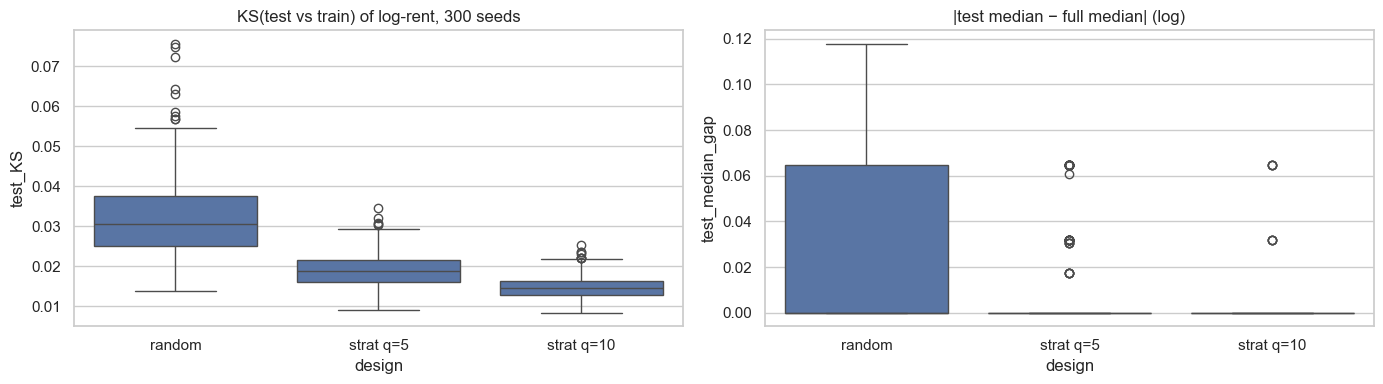

In [7]:
def make_bins(y, q):
    return pd.qcut(y, q=q, labels=False, duplicates="drop")

def split_idx(y, seed, bins=None):
    idx = np.arange(len(y))
    tmp, te = train_test_split(idx, test_size=0.15, random_state=seed, stratify=None if bins is None else bins)
    tr, va = train_test_split(tmp, test_size=0.1765, random_state=seed, stratify=None if bins is None else bins[tmp])
    return tr, va, te

ly = log_y.to_numpy()
bins5, bins10 = make_bins(y_all, 5).to_numpy(), make_bins(y_all, 10).to_numpy()
print("q=5 bin edges (₹):", pd.qcut(y_all, 5, duplicates="drop").cat.categories.astype(str).tolist())
print("q=5 bin counts   :", np.bincount(bins5).tolist())

rows = []
for seed in range(300):
    for name, b in [("random", None), ("strat q=5", bins5), ("strat q=10", bins10)]:
        tr, va, te = split_idx(ly, seed, b)
        rows.append({"design": name, "seed": seed,
                     "val_median_gap": abs(np.median(ly[va]) - np.median(ly)),
                     "test_median_gap": abs(np.median(ly[te]) - np.median(ly)),
                     "val_KS": stats.ks_2samp(ly[va], ly[tr]).statistic,
                     "test_KS": stats.ks_2samp(ly[te], ly[tr]).statistic,
                     "test_top5%_share": (y_all.to_numpy()[te] >= y_all.quantile(.95)).mean()})
sim = pd.DataFrame(rows)
agg = sim.groupby("design").agg(
    val_median_gap_mean=("val_median_gap", "mean"), test_median_gap_mean=("test_median_gap", "mean"),
    val_KS_mean=("val_KS", "mean"), test_KS_mean=("test_KS", "mean"), test_KS_p95=("test_KS", lambda s: s.quantile(.95)),
    test_top5_share_sd=("test_top5%_share", "std"))
display(agg.round(4))
print("(lower = split distributions closer to each other; target top-5% share is 0.05)")

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
sns.boxplot(data=sim, x="design", y="test_KS", ax=ax[0]); ax[0].set_title("KS(test vs train) of log-rent, 300 seeds")
sns.boxplot(data=sim, x="design", y="test_median_gap", ax=ax[1]); ax[1].set_title("|test median − full median| (log)")
plt.tight_layout(); plt.show()

## 3. The actual split — exact Phase-5 recipe (rules → `qcut` bins → two-step split, seed 42)
Section 2 shows **q=10 beats q=5 on every balance metric** (median gap ≈9x smaller, KS ≈25% smaller, tail share
less variable), with ≈470 rows per bin (≈71 per bin in val/test), so `STRAT_Q = 10`.

In [8]:
STRAT_Q = 10
bins = pd.qcut(y_all, q=STRAT_Q, labels=False, duplicates="drop")      # for splitting ONLY — never a feature
N_BINS = int(bins.nunique())
print("Bins actually formed:", N_BINS, "| counts:", bins.value_counts().sort_index().tolist())
X_all = clean.drop(columns=[TARGET])

X_temp, X_test, y_temp, y_test = train_test_split(
    X_all, y_all, test_size=0.15, random_state=RANDOM_STATE, stratify=bins)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765, random_state=RANDOM_STATE, stratify=bins.loc[X_temp.index])

n = len(clean)
print(f"Train {len(X_train)} ({len(X_train)/n:.1%}) | Val {len(X_val)} ({len(X_val)/n:.1%}) | Test {len(X_test)} ({len(X_test)/n:.1%})")
assert not (set(X_train.index) & set(X_val.index) | set(X_train.index) & set(X_test.index) | set(X_val.index) & set(X_test.index))
h = lambda idx: hashlib.sha256(np.sort(np.asarray(idx)).tobytes()).hexdigest()[:16]
print("Index hashes (Phase 5 must reproduce): train", h(X_train.index), "| val", h(X_val.index), "| test", h(X_test.index))

bal = pd.DataFrame({k: np.log1p(v).quantile([.05, .25, .5, .75, .95]) for k, v in
                    {"train": y_train, "val": y_val, "test": y_test}.items()}).T.round(3)
bal["bin_shares"] = [np.round(np.bincount(bins.loc[i.index], minlength=N_BINS) / len(i), 3).tolist()
                     for i in (y_train, y_val, y_test)]
print("Split balance (log1p quantiles + bin shares) — summary only:")
display(bal)
print("City share by split (%):")
display((pd.concat({"train": X_train["City"].value_counts(normalize=True), "val": X_val["City"].value_counts(normalize=True),
                    "test": X_test["City"].value_counts(normalize=True)}, axis=1) * 100).round(1))

Bins actually formed: 10 | counts: [543, 477, 435, 449, 540, 458, 429, 491, 444, 471]
Train 3315 (70.0%) | Val 711 (15.0%) | Test 711 (15.0%)
Index hashes (Phase 5 must reproduce): train 82bf32b8437a934e | val 55e1909c244731ec | test 1874e7d6b55e66dd
Split balance (log1p quantiles + bin shares) — summary only:


,0.05,0.25,0.5,0.75,0.95,bin_shares
train,8.700,9.21,9.68,10.404,11.775,"[0.115, 0.101, 0.092, 0.095, 0.114, 0.097, 0.0..."
val,8.613,9.21,9.68,10.358,11.735,"[0.115, 0.1, 0.091, 0.094, 0.114, 0.097, 0.09,..."
test,8.613,9.21,9.68,10.434,11.513,"[0.114, 0.101, 0.091, 0.094, 0.114, 0.097, 0.0..."


City share by split (%):


,train,val,test
City,,,
Mumbai,20.4,19.1,22.1
Bangalore,18.8,20.1,16.9
Chennai,18.4,20.3,19.3
Hyderabad,18.0,18.3,19.8
Delhi,12.9,12.5,12.0
Kolkata,11.6,9.7,10.0


In [9]:
# Phase-2 train-only far-out filter (same order as Phase 5) — val/test untouched
keep, far_info = train_only_far_out_mask(X_train, y_train, k=3.0)
print("Train-only far-out filter:", far_info)
print("Dropped train rows:")
display(X_train.loc[~keep, ["BHK", "Size", "City", "Area Locality"]].assign(Rent=y_train[~keep]))
# Look-only: where did the 2 rows flagged in Phase 2 §4 (full-data k=3 fence) land?
_r = np.log(y_all / clean["Size"]); _q1, _q3 = _r.quantile([.25, .75])
_flag = clean.index[(_r < _q1 - 3 * (_q3 - _q1)) | (_r > _q3 + 3 * (_q3 - _q1))]
for s, i in (("train", y_train), ("val", y_val), ("test", y_test)):
    print(f"  in {s:5s}:", clean.loc[_flag.intersection(i.index), ["Rent", "Size", "BHK", "City"]].to_dict("records"))
X_tr, y_tr = X_train.loc[keep], y_train.loc[keep]
print("Train after filter:", X_tr.shape)

Train-only far-out filter: {'k': 3.0, 'rent_per_sqft_lower': 0.4369066666666667, 'rent_per_sqft_upper': 1271.5657552083335, 'n_dropped': 2}
Dropped train rows:


,BHK,Size,City,Area Locality,Rent
4644,3,10,Hyderabad,ghatkesar nh 2 2,15000
1833,3,2500,Bangalore,marathahalli,3500000


  in train: [{'Rent': 3500000, 'Size': 2500, 'BHK': 3, 'City': 'Bangalore'}, {'Rent': 15000, 'Size': 10, 'BHK': 3, 'City': 'Hyderabad'}]
  in val  : []
  in test : []
Train after filter: (3313, 14)


## 4. log1p decision — TRAIN-ONLY evidence

,raw,log1p,sqrt
skew,6.008,0.889,2.622
kurtosis,57.678,0.712,9.771


Box-Cox MLE lambda on train = -0.344  (0 ⇒ log is the optimal power transform; 0.5 ⇒ sqrt; 1 ⇒ none)
95% CI for lambda: (-0.376, -0.311)

slope of log(std) vs log(mean) across 24 City×BHK groups = 0.99 (≈1 ⇒ multiplicative errors ⇒ log stabilises variance; ≈0 ⇒ additive)


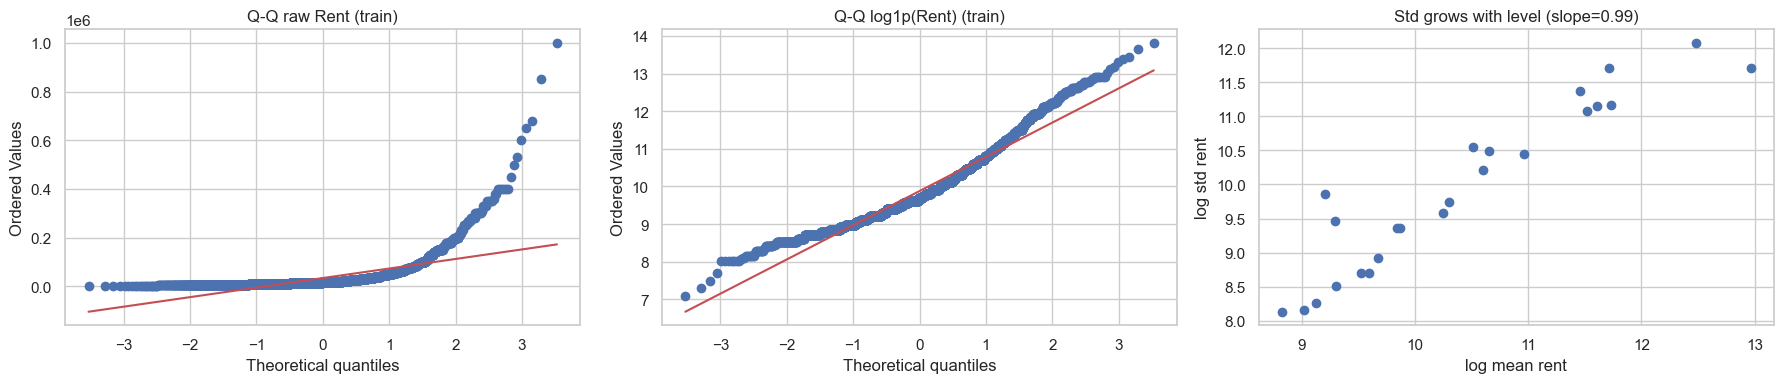

In [10]:
ly_tr = np.log1p(y_tr)
bc_y, bc_lambda = stats.boxcox(y_tr.astype(float))
display(pd.DataFrame({"raw": [y_tr.skew(), y_tr.kurt()], "log1p": [ly_tr.skew(), ly_tr.kurt()],
                      "sqrt": [np.sqrt(y_tr).skew(), np.sqrt(y_tr).kurt()]}, index=["skew", "kurtosis"]).round(3))
print(f"Box-Cox MLE lambda on train = {bc_lambda:.3f}  (0 ⇒ log is the optimal power transform; 0.5 ⇒ sqrt; 1 ⇒ none)")
lam_ci = stats.boxcox(y_tr.astype(float), alpha=0.05)[2]
print(f"95% CI for lambda: ({lam_ci[0]:.3f}, {lam_ci[1]:.3f})")

# Multiplicative noise check: within groups, does std grow proportionally with mean?
g = pd.DataFrame({"y": y_tr, "City": X_tr["City"], "BHK": X_tr["BHK"]}).groupby(["City", "BHK"])["y"].agg(["mean", "std", "count"])
g = g[g["count"] >= 10]
slope = np.polyfit(np.log(g["mean"]), np.log(g["std"]), 1)[0]
print(f"\nslope of log(std) vs log(mean) across {len(g)} City×BHK groups = {slope:.2f} "
      "(≈1 ⇒ multiplicative errors ⇒ log stabilises variance; ≈0 ⇒ additive)")

fig, ax = plt.subplots(1, 3, figsize=(18, 4))
stats.probplot(y_tr, dist="norm", plot=ax[0]); ax[0].set_title("Q-Q raw Rent (train)")
stats.probplot(ly_tr, dist="norm", plot=ax[1]); ax[1].set_title("Q-Q log1p(Rent) (train)")
ax[2].scatter(np.log(g["mean"]), np.log(g["std"])); ax[2].set_xlabel("log mean rent"); ax[2].set_ylabel("log std rent")
ax[2].set_title(f"Std grows with level (slope={slope:.2f})")
plt.tight_layout(); plt.show()

### 4a. Train-only 5-fold CV: raw target vs `log1p` target
A *minimal* fixed feature set (Phase-4 engineering not applied yet). Both arms get **identical X**, and every
transform sits inside the Pipeline, so it is re-fit within each fold. Metrics are in **rupees**
(`TransformedTargetRegressor` applies `expm1` automatically).

In [11]:
num = ["BHK", "Size", "Bathroom", "current_floor", "total_floors"]
cat = ["City", "Furnishing Status", "Area Type", "Tenant Preferred", "Point of Contact"]

def preprocessor(scale):
    num_steps = [("impute", SimpleImputer(strategy="median"))] + ([("scale", StandardScaler())] if scale else [])
    return ColumnTransformer([
        ("size", Pipeline([("clip", LogIQRClipper(k=1.5, side="lower"))] + ([("scale", StandardScaler())] if scale else [])), ["Size"]),
        ("num", Pipeline(num_steps), [c for c in num if c != "Size"]),
        ("cat", OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=10, sparse_output=False), cat),
    ])

models = {"Ridge": (Ridge(alpha=1.0), True),
          "HistGB": (HistGradientBoostingRegressor(random_state=RANDOM_STATE), False)}
scoring = {"rmse": make_scorer(lambda a, p: np.sqrt(mean_squared_error(a, p)), greater_is_better=False),
           "mae": make_scorer(mean_absolute_error, greater_is_better=False),
           "r2": make_scorer(r2_score),
           "rmsle": make_scorer(lambda a, p: np.sqrt(mean_squared_error(np.log1p(a), np.log1p(np.clip(p, 0, None)))),
                                greater_is_better=False)}
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

res = []
for mname, (est, scale) in models.items():
    for tname in ["raw", "log1p"]:
        reg = Pipeline([("prep", preprocessor(scale)), ("model", clone(est))])
        if tname == "log1p":
            reg = TransformedTargetRegressor(regressor=reg, func=np.log1p, inverse_func=np.expm1)
        t0 = time.perf_counter()
        s = cross_validate(reg, X_tr, y_tr, cv=cv, scoring=scoring)
        res.append({"model": mname, "target": tname,
                    "CV RMSE (₹)": -s["test_rmse"].mean(), "RMSE sd": s["test_rmse"].std(),
                    "CV MAE (₹)": -s["test_mae"].mean(), "CV R²": s["test_r2"].mean(),
                    "CV RMSLE": -s["test_rmsle"].mean(), "time_s": time.perf_counter() - t0})
res = pd.DataFrame(res).set_index(["model", "target"])
display(res.round({"CV RMSE (₹)": 0, "RMSE sd": 0, "CV MAE (₹)": 0, "CV R²": 4, "CV RMSLE": 4, "time_s": 2}))

CV RMSE (₹)  RMSE sd  CV MAE (₹)   CV R²  CV RMSLE  time_s
model  target                                                            
Ridge  raw         38255.0   7286.0     20667.0  0.5609    4.0826    0.11
       log1p       32839.0   6119.0     11438.0  0.6698    0.3865    0.10
HistGB raw         29940.0   6227.0     11616.0  0.7286    0.4347    2.85
       log1p       30035.0   7026.0     10632.0  0.7288    0.3750    2.96

In [12]:
# Where do the two targets differ? Out-of-fold errors by rent band (Ridge, train only)
from sklearn.model_selection import cross_val_predict
oof = {}
for tname in ["raw", "log1p"]:
    reg = Pipeline([("prep", preprocessor(True)), ("model", Ridge(alpha=1.0))])
    if tname == "log1p":
        reg = TransformedTargetRegressor(regressor=reg, func=np.log1p, inverse_func=np.expm1)
    oof[tname] = cross_val_predict(reg, X_tr, y_tr, cv=cv)
band_tr = pd.qcut(y_tr, 5, labels=["Q1 low", "Q2", "Q3", "Q4", "Q5 high"])
err = pd.DataFrame({t: (pd.Series(np.abs(p - y_tr.to_numpy()), index=y_tr.index) / y_tr).groupby(band_tr, observed=True).median()
                    for t, p in oof.items()})
err.columns = [f"median |% error| — {c}" for c in err.columns]
display((err * 100).round(1))
print("Negative predictions (impossible rents):", {t: int((p < 0).sum()) for t, p in oof.items()})

,median |% error| — raw,median |% error| — log1p
Rent,,
Q1 low,197.5,25.0
Q2,70.3,17.9
Q3,65.8,20.8
Q4,62.6,24.9
Q5 high,35.9,26.4


Negative predictions (impossible rents): {'raw': 665, 'log1p': 0}


## 5. Robustness check of the Phase-2 far-out rule (global vs per-City)
The Phase-2 rule uses **one global** fence on `log(Rent/Size)`. Mumbai's price per sqft is 3–5x every other
city's, so the global fence is wide, and a ₹1,400/sqft Bangalore listing can slip under it.
**Candidate alternative** (methodology, not row-picking): compute the same Tukey far-out fence (k=3, unchanged)
**per City**, on `Rent / clipped Size`. Clipped Size is used because Phase 2 found tiny sizes are *size* errors,
already fixed by the clipper, so they should not make a correct rent look anomalous.

**Honest comparison:** in each CV fold the filter is fitted on and applied to the fold-train rows only, and every
fold-val row is scored. That mirrors the real policy (val/test never filtered).

In [13]:
def train_only_far_out_mask_by_city(X_train, y_train, k=3.0, clip_k=1.5):
    """CANDIDATE alternative: per-City Tukey far-out fences on log(Rent / clipped Size), computed on TRAIN.
    Returns a keep-mask for TRAIN rows only. Never call on val/test."""
    size = LogIQRClipper(k=clip_k, side="lower").fit(X_train[["Size"]]).transform(X_train[["Size"]]).ravel()
    r = pd.Series(np.log(np.asarray(y_train, dtype="float64") / size), index=X_train.index)
    city = X_train["City"]
    q = r.groupby(city).quantile([.25, .75]).unstack(); iqr = q[.75] - q[.25]
    lo, hi = city.map(q[.25] - k * iqr), city.map(q[.75] + k * iqr)
    keep = ((r >= lo) & (r <= hi)).to_numpy()
    return keep, {"k": k, "n_dropped": int((~keep).sum()),
                  "fences_rent_per_sqft": pd.DataFrame({"lo": np.exp(q[.25] - k * iqr), "hi": np.exp(q[.75] + k * iqr)}).round(1)}

keep_city, info_city = train_only_far_out_mask_by_city(X_train, y_train)
print("Per-city rule on this train split drops", info_city["n_dropped"], "rows:")
display(X_train.loc[~keep_city, ["BHK", "Bathroom", "Size", "City", "Area Locality", "Furnishing Status"]].assign(Rent=y_train[~keep_city]))
display(info_city["fences_rent_per_sqft"])

Per-city rule on this train split drops 7 rows:


,BHK,Bathroom,Size,City,Area Locality,Furnishing Status,Rent
4067,3,3,2100,Hyderabad,uppal nh 2 2,Furnished,1200
3913,3,3,25,Hyderabad,sanath nagar nh 9,Semi-Furnished,23000
104,2,2,950,Kolkata,avenue s santoshpur,Unfurnished,180000
710,2,2,790,Mumbai,deep heights nalasopara,Unfurnished,6500
1833,3,3,2500,Bangalore,marathahalli,Semi-Furnished,3500000
4108,3,3,150,Hyderabad,jubilee hills,Unfurnished,37000
461,3,2,120,Kolkata,ca 150 sector 1 saltlake,Furnished,34000


,lo,hi
City,,
Bangalore,3.0,104.5
Chennai,2.2,124.3
Delhi,1.3,673.4
Hyderabad,1.7,127.5
Kolkata,2.0,99.7
Mumbai,9.2,599.7


In [14]:
FILTERS = {"none": lambda X, y: np.ones(len(X), bool),
           "global k=3 (Phase 2)": lambda X, y: train_only_far_out_mask(X, y, k=3.0)[0],
           "per-City k=3 (candidate)": lambda X, y: train_only_far_out_mask_by_city(X, y, k=3.0)[0]}

def honest_cv(make_model, filt, X, y):
    out = []
    for tr_i, va_i in cv.split(X):
        Xf, yf = X.iloc[tr_i], y.iloc[tr_i]
        m = filt(Xf, yf)
        p = make_model().fit(Xf[m], yf[m]).predict(X.iloc[va_i])
        a = y.iloc[va_i].to_numpy()
        out.append([np.sqrt(mean_squared_error(a, p)), mean_absolute_error(a, p), r2_score(a, p),
                    np.sqrt(mean_squared_error(np.log1p(a), np.log1p(np.clip(p, 0, None))))])
    out = np.array(out)
    return {"CV RMSE (₹)": out[:, 0].mean(), "RMSE sd": out[:, 0].std(), "CV MAE (₹)": out[:, 1].mean(),
            "CV R²": out[:, 2].mean(), "CV RMSLE": out[:, 3].mean()}

LOG_MODELS = {
    "Ridge·log1p": lambda: TransformedTargetRegressor(Pipeline([("prep", preprocessor(True)), ("model", Ridge(alpha=1.0))]),
                                                      func=np.log1p, inverse_func=np.expm1),
    "HistGB·log1p": lambda: TransformedTargetRegressor(Pipeline([("prep", preprocessor(False)),
                                                                 ("model", HistGradientBoostingRegressor(random_state=RANDOM_STATE))]),
                                                       func=np.log1p, inverse_func=np.expm1)}
fres = pd.DataFrame([{"model": mn, "train filter": fn, **honest_cv(mf, ff, X_train, y_train)}
                     for mn, mf in LOG_MODELS.items() for fn, ff in FILTERS.items()]).set_index(["model", "train filter"])
display(fres.round({"CV RMSE (₹)": 0, "RMSE sd": 0, "CV MAE (₹)": 0, "CV R²": 4, "CV RMSLE": 4}))
print("All fold-val rows are scored in every arm, so the rows are identical across filters → apples-to-apples.")

CV RMSE (₹)  RMSE sd  CV MAE (₹)   CV R²  CV RMSLE
model        train filter                                                                
Ridge·log1p  none                          52750.0  43236.0     12459.0  0.5706    0.3919
             global k=3 (Phase 2)          52548.0  43336.0     12425.0  0.5752    0.3918
             per-City k=3 (candidate)      52663.0  43264.0     12442.0  0.5726    0.3918
HistGB·log1p none                          49992.0  43908.0     11605.0  0.6234    0.3790
             global k=3 (Phase 2)          49994.0  43876.0     11601.0  0.6226    0.3782
             per-City k=3 (candidate)      49890.0  43914.0     11497.0  0.6246    0.3776

All fold-val rows are scored in every arm, so the rows are identical across filters → apples-to-apples.



## 6. Phase-3 decisions

| # | Decision | Evidence |
|---|---|---|
| P3-1 | **No resampling.** No SMOTE, over- or under-sampling, and no sample weights. | This is regression. The sparse high range (1–5L+ is about 6.7% of rows, mostly Mumbai) is real market data, not class imbalance. |
| P3-2 | **Stratify the split on `pd.qcut(y, q=10, duplicates="drop")`**, which overrides the plan's default of q=5. The bins are used **only** for `stratify=` and never become a feature. | Over 300 seeds, q=10 cut the median gap between split and full data from 0.026 (random) / 0.009 (q=5) to **0.001** in log space. KS(test vs train) fell from 0.032 / 0.019 to **0.015**, and the top-5% share is less variable. All 10 bins formed (429–543 rows each). |
| P3-3 | **Split recipe for Phase 5:** rules → q=10 bins → `test_size=0.15`, then `0.1765` of the remainder, `random_state=42`, stratified both times → **3,315 / 711 / 711** rows. | Index hashes Phase 5 must reproduce: train `82bf32b8437a934e`, val `55e1909c244731ec`, test `1874e7d6b55e66dd` (train hash taken *before* the far-out filter). |
| P3-4 | **Train on `log1p(Rent)` and back-transform with `np.expm1`.** Every metric is reported in rupees. | Train-only checks: skew 6.0 → **0.89**. The ratio of spread to mean rent is about **0.99** across 24 City×BHK groups, which means errors scale with rent level, exactly what log handles. In 5-fold CV on train, Ridge improves on every metric (RMSE ₹38.3k → **₹32.8k**, MAE ₹20.7k → **₹11.4k**, R² 0.56 → **0.67**), and on the raw target Ridge predicts **665 negative rents**. HistGB ties on RMSE (₹29.9k vs ₹30.0k) but wins on MAE (₹11.6k → **₹10.6k**) and RMSLE. Raw-target errors are lopsided (median 197% off on the cheapest fifth of rents vs 36% on the priciest), while log1p keeps them even at **18–26%**. |
| P3-5 | Box-Cox was considered and **rejected**. | λ = −0.34 (CI −0.38 to −0.31) would make the raw rent distribution itself most bell-shaped. What matters for modelling is the error structure, and the ratio of about 1.0 points to log. log1p is also the transform `CLAUDE.md` prescribes, and it is easy to interpret. |
| P3-6 | **Keep the Phase-2 global far-out rule unchanged.** No amendment. | On the q=10 split, both data errors land in train and the global rule drops exactly those two (₹35L Marathahalli; the 10 sqft 3 BHK). The per-City alternative drops 7 rows, including plausible ones (₹6.5k in Nalasopara, ₹37k in Jubilee Hills). In the fair CV comparison (filter fold-train only, score every fold-val row), the three options differ by **< 0.5%** on every metric, so the rule only removes data errors and doesn't change model quality. |
| P3-7 | **One row dominates rupee RMSE.** | When the ₹35L row is scored (section 5, unfiltered fold-val), CV RMSE jumps from about ₹30–33k to about ₹50k and the fold-to-fold sd from about ₹6k to about ₹43k. In Phase 5 that row is in train and gets filtered, so model-notebook CV and validation won't be dominated by it. Every summary still reports MAE and R² alongside RMSE. |

### Effects on later phases
* **Phase 4:** engineer features on the rule-cleaned frame. Anything derived from `Size` goes after the clipper.
* **Phase 5:** recipe as in P3-3, then the global far-out mask on train (expect 2 rows dropped → train 3,313), then fit the ColumnTransformer on train. The bundle stores **y in rupees** with `target_transform="log1p"`. Model notebooks wrap the estimator as `TransformedTargetRegressor(func=np.log1p, inverse_func=np.expm1)`, so CV RMSE and every other metric come out in rupees automatically.
* **Known caveat:** `expm1` of a log-scale prediction estimates the *median* rent, not the mean, so rupee RMSE carries a small downward bias. This is noted for the Phase 9/10 interpretation, not corrected.
